# Barcode Count Parameter Sweep Analysis

This notebook analyzes the effect of barcode count on the performance of barcode calling tools.

**Experiment Overview:**
- **Tools**: RandomBarcodes, QUIK, Columba
- **Barcode Counts**: 21,000 / 42,000 / 85,000
- **Barcode Lengths**: 28nt and 36nt
- **Total Reads**: 200,000
- **Objective**: Evaluate how increasing barcode count affects optimal rejection thresholds and precision/recall tradeoffs

**Rejection Thresholds Tested:**
- RandomBarcodes: ntriage=100, nthresh=[5,6,7,8,9]
- QUIK: strategy=4_mer_gpu_v4, rejection_threshold=[5,6,7,8,9]
- Columba: cpus=8, identity_threshold=[77,78,79,80,81,82]

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
palette = sns.color_palette("Set2")
sns.set_palette(palette)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

## 1. Configuration and Data Loading

In [12]:
# Configuration
TOOLS = {
    'randombarcodes': {
        'name': 'RandomBarcodes',
        'thresholds': [5, 6, 7, 8, 9],
        'threshold_param': 'nthresh',
        'fixed_params': {'ntriage': 100, 'gpus': 1}
    },
    'quik': {
        'name': 'QUIK',
        'thresholds': [5, 6, 7, 8, 9],
        'threshold_param': 'rejection_threshold',
        'fixed_params': {'strategy': '4_mer_gpu_v4', 'gpus': 1}
    },
    'columba': {
        'name': 'Columba',
        'thresholds': [77, 78, 79, 80, 81, 82],
        'threshold_param': 'identity_threshold',
        'fixed_params': {'cpus': 8}
    }
}

BARCODE_COUNTS = [21000, 42000, 85000]
BARCODE_LENGTHS = [28, 36]
TOTAL_READS = 200000

RESULTS_PATH = Path("../results/barcode_count_sweep")

# Previous experiment paths for 21K results
# PREVIOUS_RESULTS_28NT = Path("/user/gent/446/vsc44685/ScratchVO_dir/barcalling_review/results_sweep/results_28nt/new_summaries/summary_all_metrics.csv")
# PREVIOUS_RESULTS_36NT = Path("/user/gent/446/vsc44685/ScratchVO_dir/barcalling_review/results_sweep/results_36nt/new_summaries/summary_all_metrics.csv")

print("Configuration loaded:")
print(f"  Tools: {list(TOOLS.keys())}")
print(f"  Barcode counts: {BARCODE_COUNTS}")
print(f"  Barcode lengths: {BARCODE_LENGTHS}")
print(f"  New results path (42K/85K): {RESULTS_PATH}")
# print(f"  Previous 21K results (28nt): {PREVIOUS_RESULTS_28NT}")
# print(f"  Previous 21K results (36nt): {PREVIOUS_RESULTS_36NT}")

Configuration loaded:
  Tools: ['randombarcodes', 'quik', 'columba']
  Barcode counts: [21000, 42000, 85000]
  Barcode lengths: [28, 36]
  New results path (42K/85K): ../results/barcode_count_sweep


### 1.1 Data Loading Functions

In [13]:

def load_results_for_tool(tool_name, barcode_count, barcode_length, threshold):
    """
    Load results for all tools from new parameter sweep (21K/42K/85K).
    
    Results directory structure:
    - results/barcode_count_sweep/randombarcodes/21K_28nt/t100_n5/RB_21K_28nt_t100_n5_*
    - results/barcode_count_sweep/quik/21K_28nt/4mer_r5/QUIK_21K_28nt_4mer_r5_*
    - results/barcode_count_sweep/columba/21K_28nt/I77/Columba_21K_28nt_I77_*
    
    Returns:
        dict: Results containing metrics, or None if not found
    """
    count_label = f"{barcode_count//1000}K"
    
    # Construct path to results
    if tool_name == 'randombarcodes':
        sample_id = f"RB_{count_label}_{barcode_length}nt_t100_n{threshold}"
        results_dir = RESULTS_PATH / "randombarcodes" / f"{count_label}_{barcode_length}nt" / f"t100_n{threshold}"
    elif tool_name == 'quik':
        sample_id = f"QUIK_{count_label}_{barcode_length}nt_4mer_r{threshold}"
        results_dir = RESULTS_PATH / "quik" / f"{count_label}_{barcode_length}nt" / f"4mer_r{threshold}"
    elif tool_name == 'columba':
        sample_id = f"Columba_{count_label}_{barcode_length}nt_I{threshold}"
        results_dir = RESULTS_PATH / "columba" / f"{count_label}_{barcode_length}nt" / f"I{threshold}"
    else:
        return None
    
    # Look for CSV summary file (more structured than txt)
    summary_csv = results_dir / f"{sample_id}_precision_summary.csv"
    
    if not summary_csv.exists():
        return None
    
    # Parse CSV summary file
    results = {
        'tool': TOOLS[tool_name]['name'],
        'tool_key': tool_name,
        'barcode_count': barcode_count,
        'barcode_length': barcode_length,
        'threshold': threshold,
        'sample_id': sample_id
    }
    
    # Read CSV file
    df_summary = pd.read_csv(summary_csv)
    
    # Convert to dictionary (metric -> value)
    for _, row in df_summary.iterrows():
        metric = row['metric']
        value = row['value']
        
        # Map CSV metrics to standard names
        metric_map = {
            'precision_percent': 'precision',
            'recall_percent': 'recall',
            'accuracy_percent': 'accuracy',
            'assignment_rate_percent': 'assignment_rate',
            'total_reads': 'total_reads',
            'total_assigned': 'assigned',
            'correct_assignments': 'correct',
            'incorrect_assignments': 'incorrect',
            'unassigned_reads': 'unassigned'
        }
        
        standard_metric = metric_map.get(metric, metric)
        results[standard_metric] = value
    
    # Calculate F1 score if not present
    if 'precision' in results and 'recall' in results:
        p = results['precision']
        r = results['recall']
        if p + r > 0:
            results['f1_score'] = 2 * (p * r) / (p + r)
        else:
            results['f1_score'] = 0.0
    
    return results


test_result = load_results_for_tool('quik', 21000, 28, 5)
if test_result:
    print("\n✓ Successfully loaded test result from new parameter sweep (QUIK 21K)")
    print(f"  Sample: {test_result.get('sample_id', 'N/A')}")
else:
    print("\n⚠️  Could not load test result from new sweep (jobs may still be running)")


✓ Successfully loaded test result from new parameter sweep (QUIK 21K)
  Sample: QUIK_21K_28nt_4mer_r5


In [14]:
test_result = load_results_for_tool('randombarcodes', 85000, 36, 5)
if test_result:
    print("\n✓ Successfully loaded test result from new parameter sweep (QUIK 21K)")
    print(f"  Sample: {test_result.get('sample_id', 'N/A')}")
else:
    print("\n⚠️  Could not load test result from new sweep (jobs may still be running)")


✓ Successfully loaded test result from new parameter sweep (QUIK 21K)
  Sample: RB_85K_36nt_t100_n5


### 1.2 Load All Results

In [15]:
all_results = []

for tool_name, tool_config in TOOLS.items():
    print(f"\n  Tool: {tool_config['name']}")
    
    for barcode_count in [21000, 42000, 85000]:    
        for barcode_length in BARCODE_LENGTHS:
            for threshold in tool_config['thresholds']:
                result = load_results_for_tool(tool_name, barcode_count, barcode_length, threshold)
                if result is not None:
                    all_results.append(result)
        
        # Count results for this barcode count
        count_results = [r for r in all_results if r['tool_key'] == tool_name and r['barcode_count'] == barcode_count]
        print(f"    {barcode_count//1000}K: {len(count_results)} results")

# Combine: Previous 21K RandomBarcodes + New sweep (everything else)
df_all = pd.DataFrame(all_results)

print("\n" + "=" * 80)
print("DATA LOADING COMPLETE")
print("=" * 80)
print(f"\nTotal results loaded: {len(df_all)}")
print(f"  - All other results (from new sweep): {len(all_results)}")
print(f"\nBreakdown by tool:")
for tool_name, tool_config in TOOLS.items():
    tool_results = df_all[df_all['tool_key'] == tool_name]
    print(f"  {tool_config['name']}: {len(tool_results)} results")
    for bc in [21000, 42000, 85000]:
        count = len(tool_results[tool_results['barcode_count'] == bc])
        print(f"    {bc//1000}K: {count}")

# # Standardize metric names across both sources
# df_all['tool'] = df_all.apply(lambda x: TOOLS[x['tool_key']]['name'], axis=1)

# # Display sample
# print("\n" + "=" * 80)
# print("SAMPLE DATA (first 3 rows)")
# print("=" * 80)
# display_cols = ['tool', 'barcode_count', 'barcode_length', 'threshold', 'precision', 'recall', 'f1_score']
# print(df_all[display_cols].head(3).to_string(index=False))


  Tool: RandomBarcodes
    21K: 1 results
    42K: 0 results
    85K: 1 results

  Tool: QUIK
    21K: 2 results
    42K: 0 results
    85K: 0 results

  Tool: Columba
    21K: 2 results
    42K: 0 results
    85K: 0 results

DATA LOADING COMPLETE

Total results loaded: 6
  - All other results (from new sweep): 6

Breakdown by tool:
  RandomBarcodes: 2 results
    21K: 1
    42K: 0
    85K: 1
  QUIK: 2 results
    21K: 2
    42K: 0
    85K: 0
  Columba: 2 results
    21K: 2
    42K: 0
    85K: 0


In [16]:
df_all.head(6)

,tool,tool_key,barcode_count,barcode_length,threshold,sample_id,total_reads,assigned,correct,incorrect,unassigned,assignment_rate,precision,recall,accuracy,f1_score,total_processed
0,RandomBarcodes,randombarcodes,21000,28,5,RB_21K_28nt_t100_n5,200000.0,72146.0,72138.0,8.0,127854.0,36.0730,99.9889,36.0690,36.0690,53.014189,NaN
1,RandomBarcodes,randombarcodes,85000,36,5,RB_85K_36nt_t100_n5,200000.0,34295.0,34295.0,0.0,165705.0,17.1475,100.0000,17.1475,17.1475,29.275059,NaN
2,QUIK,quik,21000,28,5,QUIK_21K_28nt_4mer_r5,200000.0,85976.0,85966.0,10.0,114024.0,42.9880,99.9884,42.9830,42.9830,60.121135,NaN
3,QUIK,quik,21000,36,5,QUIK_21K_36nt_4mer_r5,200000.0,114521.0,114521.0,0.0,85479.0,57.2605,100.0000,57.2605,57.2605,72.822482,NaN
4,Columba,columba,21000,28,77,Columba_21K_28nt_I77,200000.0,NaN,114183.0,2555.0,83262.0,58.3690,97.8113,57.0915,57.0915,72.099327,200000.0
5,Columba,columba,21000,36,77,Columba_21K_36nt_I77,200000.0,NaN,115612.0,149.0,84239.0,57.8805,99.8713,57.8060,57.8060,73.227540,200000.0


### 1.3 Standardize Metrics

Different tools may report metrics with different names. Let's standardize them.

In [9]:
# Standardize metric names if needed
if len(df_all) > 0:
    # Check what columns we have
    print("Available columns:")
    print(df_all.columns.tolist())
    
    # Create standardized columns if they don't exist
    if 'Precision' in df_all.columns and 'precision' not in df_all.columns:
        df_all['precision'] = df_all['Precision']
    if 'Recall' in df_all.columns and 'recall' not in df_all.columns:
        df_all['recall'] = df_all['Recall']
    if 'F1-score' in df_all.columns and 'f1_score' not in df_all.columns:
        df_all['f1_score'] = df_all['F1-score']
    
    # Calculate F1 score if not present
    if 'f1_score' not in df_all.columns and 'precision' in df_all.columns and 'recall' in df_all.columns:
        df_all['f1_score'] = 2 * (df_all['precision'] * df_all['recall']) / (df_all['precision'] + df_all['recall'])
        df_all['f1_score'] = df_all['f1_score'].fillna(0)
    
    print("\nStandardized metrics created.")
    print(f"\nMetrics available: precision, recall, f1_score")

Available columns:
['tool', 'tool_key', 'barcode_count', 'barcode_length', 'threshold', 'sample_id', 'total_reads', 'assigned', 'correct', 'incorrect', 'unassigned', 'assignment_rate', 'precision', 'recall', 'accuracy', 'f1_score', 'total_processed']

Standardized metrics created.

Metrics available: precision, recall, f1_score


In [10]:
tool = "Columba"
count = 21000
df_all[(df_all['tool'] == tool) & (df_all['barcode_count'] == count)]

,tool,tool_key,barcode_count,barcode_length,threshold,sample_id,total_reads,assigned,correct,incorrect,unassigned,assignment_rate,precision,recall,accuracy,f1_score,total_processed
3,Columba,columba,21000,28,77,Columba_21K_28nt_I77,200000.0,NaN,114183.0,2555.0,83262.0,58.3690,97.8113,57.0915,57.0915,72.099327,200000.0
4,Columba,columba,21000,36,77,Columba_21K_36nt_I77,200000.0,NaN,115612.0,149.0,84239.0,57.8805,99.8713,57.8060,57.8060,73.227540,200000.0


## 2. Exploratory Data Analysis

### 2.1 Summary Statistics

In [9]:
if len(df_all) > 0:
    # Group by tool and barcode count
    summary = df_all.groupby(['tool', 'barcode_count', 'barcode_length']).agg({
        'precision': ['mean', 'std', 'min', 'max'],
        'recall': ['mean', 'std', 'min', 'max'],
        'f1_score': ['mean', 'std', 'min', 'max']
    }).round(2)
    
    print("Summary Statistics by Tool, Barcode Count, and Length:\n")
    display(summary)

Summary Statistics by Tool, Barcode Count, and Length:



precision                        \
                                                 mean    std    min     max   
tool           barcode_count barcode_length                                   
Columba        21000         28                 99.14   1.03  97.81   99.81   
                             36                 99.97   0.05  99.87  100.00   
               42000         28                 98.31   1.97  95.77   99.58   
                             36                 99.95   0.09  99.77  100.00   
               85000         28                 96.78   3.75  91.93   99.20   
                             36                 99.90   0.18  99.53  100.00   
QUIK           21000         28                 96.50   5.09  87.92   99.99   
                             36                 99.91   0.16  99.63  100.00   
               42000         28                 94.61   7.52  82.14   99.96   
                             36                 99.83   0.30  99.31  100.00   
               85000         28                 92.05  10.33  75.46   99.91   
                             36                 99.69   0.53  98.76  100.00   
RandomBarcodes 21000         28                 96.24   5.38  87.29   99.99   
                             36                 99.98   0.02  99.95  100.00   
               42000         28                 94.51   7.24  82.96   99.98   
                             36                 99.98   0.03  99.92  100.00   
               85000         28                 92.35   9.16  78.71   99.92   
                             36                 99.97   0.05  99.88  100.00   

                                            recall                       \
                                              mean    std    min    max   
tool           barcode_count barcode_length                               
Columba        21000         28              46.31   8.35  40.92  57.09   
                             36              42.41   9.49  32.28  57.81   
               42000         28              46.13   8.24  40.81  56.77   
                             36              42.37   9.45  32.32  57.77   
               85000         28              45.83   8.00  40.67  56.15   
                             36              42.08   9.46  32.03  57.53   
QUIK           21000         28              63.78  14.03  42.98  77.34   
                             36              81.92  15.93  57.26  95.88   
               42000         28              61.26  12.55  42.27  72.90   
                             36              81.53  15.68  57.19  95.13   
               85000         28              58.56  11.10  41.51  68.41   
                             36              81.03  15.47  56.86  94.17   
RandomBarcodes 21000         28              62.48  18.59  36.07  82.02   
                             36              46.95  15.44  29.42  64.61   
               42000         28              61.70  17.82  35.93  79.69   
                             36              40.98  18.75  17.38  64.48   
               85000         28              60.76  16.92  35.85  77.05   
                             36              40.70  18.76  17.15  64.20   

                                            f1_score                       
                                                mean    std    min    max  
tool           barcode_count barcode_length                                
Columba        21000         28                62.73   7.26  58.04  72.10  
                             36                59.04   9.21  48.81  73.23  
               42000         28                62.36   6.91  57.89  71.28  
                             36                59.00   9.16  48.85  73.17  
               85000         28                61.70   6.21  57.69  69.72  
                             36                58.70   9.18  48.52  72.91  
QUIK           21000         28                75.75   9.75  60.12  83.69  
                             36                8

## 3. Performance Visualizations

### 3.1 Precision vs Threshold (by Barcode Count)

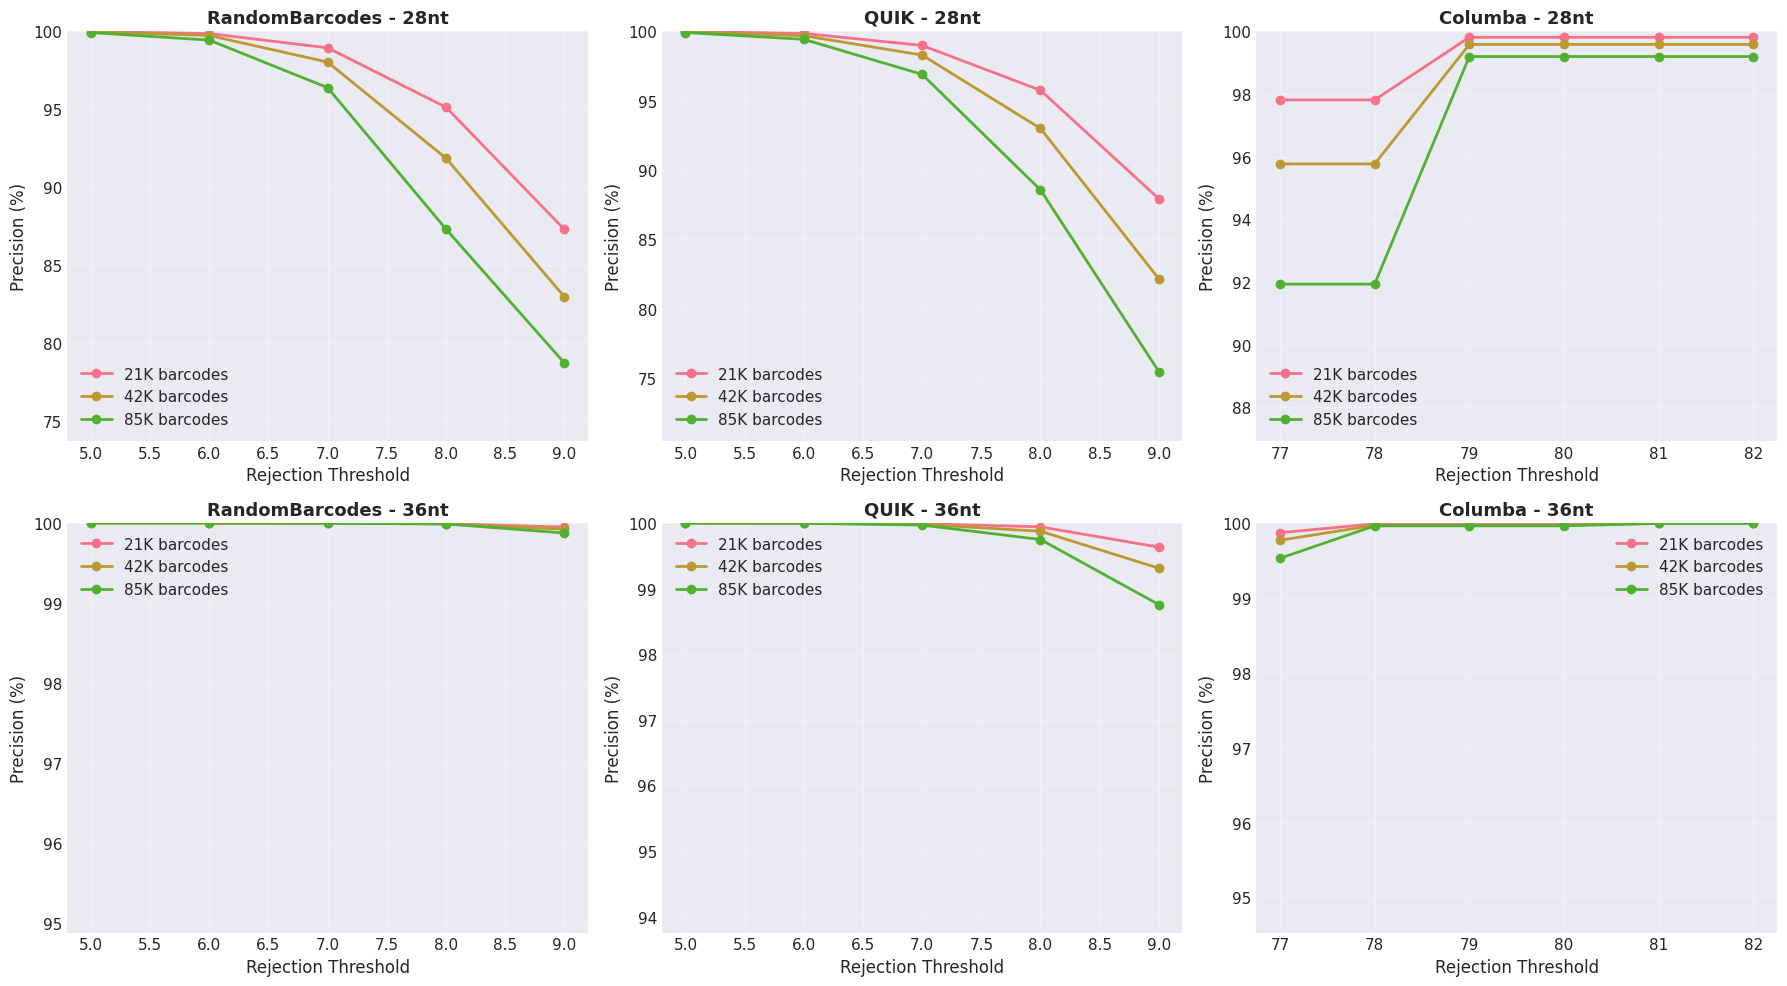

Figure saved to: notebooks/figures/barcode_count_precision_vs_threshold.png


In [8]:
if len(df_all) > 0 and 'precision' in df_all.columns:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    for i, barcode_length in enumerate(BARCODE_LENGTHS):
        for j, tool_name in enumerate(['RandomBarcodes', 'QUIK', 'Columba']):
            ax = axes[i, j]
            
            df_subset = df_all[(df_all['tool'] == tool_name) & (df_all['barcode_length'] == barcode_length)]
            
            for barcode_count in BARCODE_COUNTS:
                df_plot = df_subset[df_subset['barcode_count'] == barcode_count]
                if len(df_plot) > 0:
                    count_label = f"{barcode_count//1000}K"
                    ax.plot(df_plot['threshold'], df_plot['precision'], 
                           marker='o', label=f'{count_label} barcodes', linewidth=2)
            
            ax.set_xlabel('Rejection Threshold', fontsize=12)
            ax.set_ylabel('Precision (%)', fontsize=12)
            ax.set_title(f'{tool_name} - {barcode_length}nt', fontsize=13, fontweight='bold')
            ax.legend()
            ax.grid(True, alpha=0.3)
            if len(df_subset) > 0:
                ax.set_ylim([max(0, df_subset['precision'].min() - 5), min(100, df_subset['precision'].max() + 5)])
    
    plt.tight_layout()
    plt.savefig('/user/gent/446/vsc44685/ScratchVO_dir/barcalling_review/notebooks/figures/barcode_count_precision_vs_threshold.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Figure saved to: notebooks/figures/barcode_count_precision_vs_threshold.png")

### 3.2 Recall vs Threshold (by Barcode Count)

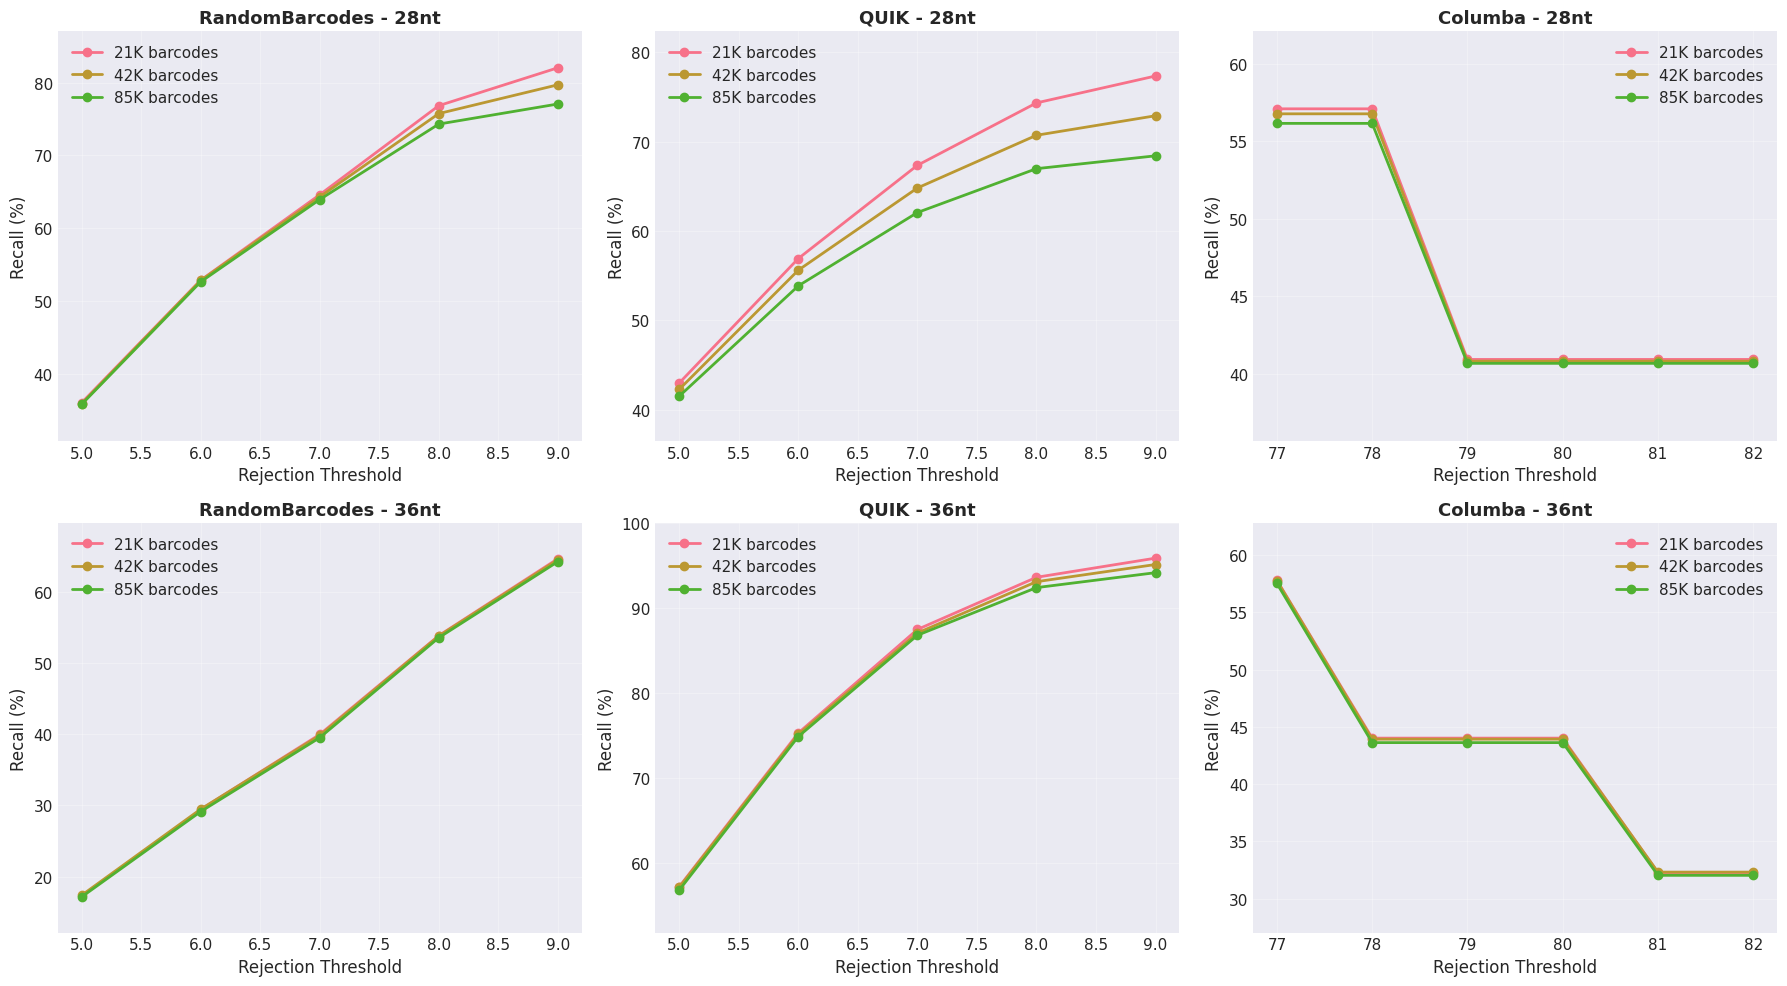

Figure saved to: notebooks/figures/barcode_count_recall_vs_threshold.png


In [9]:
if len(df_all) > 0 and 'recall' in df_all.columns:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    for i, barcode_length in enumerate(BARCODE_LENGTHS):
        for j, tool_name in enumerate(['RandomBarcodes', 'QUIK', 'Columba']):
            ax = axes[i, j]
            
            df_subset = df_all[(df_all['tool'] == tool_name) & (df_all['barcode_length'] == barcode_length)]
            
            for barcode_count in BARCODE_COUNTS:
                df_plot = df_subset[df_subset['barcode_count'] == barcode_count]
                if len(df_plot) > 0:
                    count_label = f"{barcode_count//1000}K"
                    ax.plot(df_plot['threshold'], df_plot['recall'], 
                           marker='o', label=f'{count_label} barcodes', linewidth=2)
            
            ax.set_xlabel('Rejection Threshold', fontsize=12)
            ax.set_ylabel('Recall (%)', fontsize=12)
            ax.set_title(f'{tool_name} - {barcode_length}nt', fontsize=13, fontweight='bold')
            ax.legend()
            ax.grid(True, alpha=0.3)
            if len(df_subset) > 0:
                ax.set_ylim([max(0, df_subset['recall'].min() - 5), min(100, df_subset['recall'].max() + 5)])
    
    plt.tight_layout()
    plt.savefig('/user/gent/446/vsc44685/ScratchVO_dir/barcalling_review/notebooks/figures/barcode_count_recall_vs_threshold.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Figure saved to: notebooks/figures/barcode_count_recall_vs_threshold.png")

### 3.3 F1 Score vs Threshold (by Barcode Count)

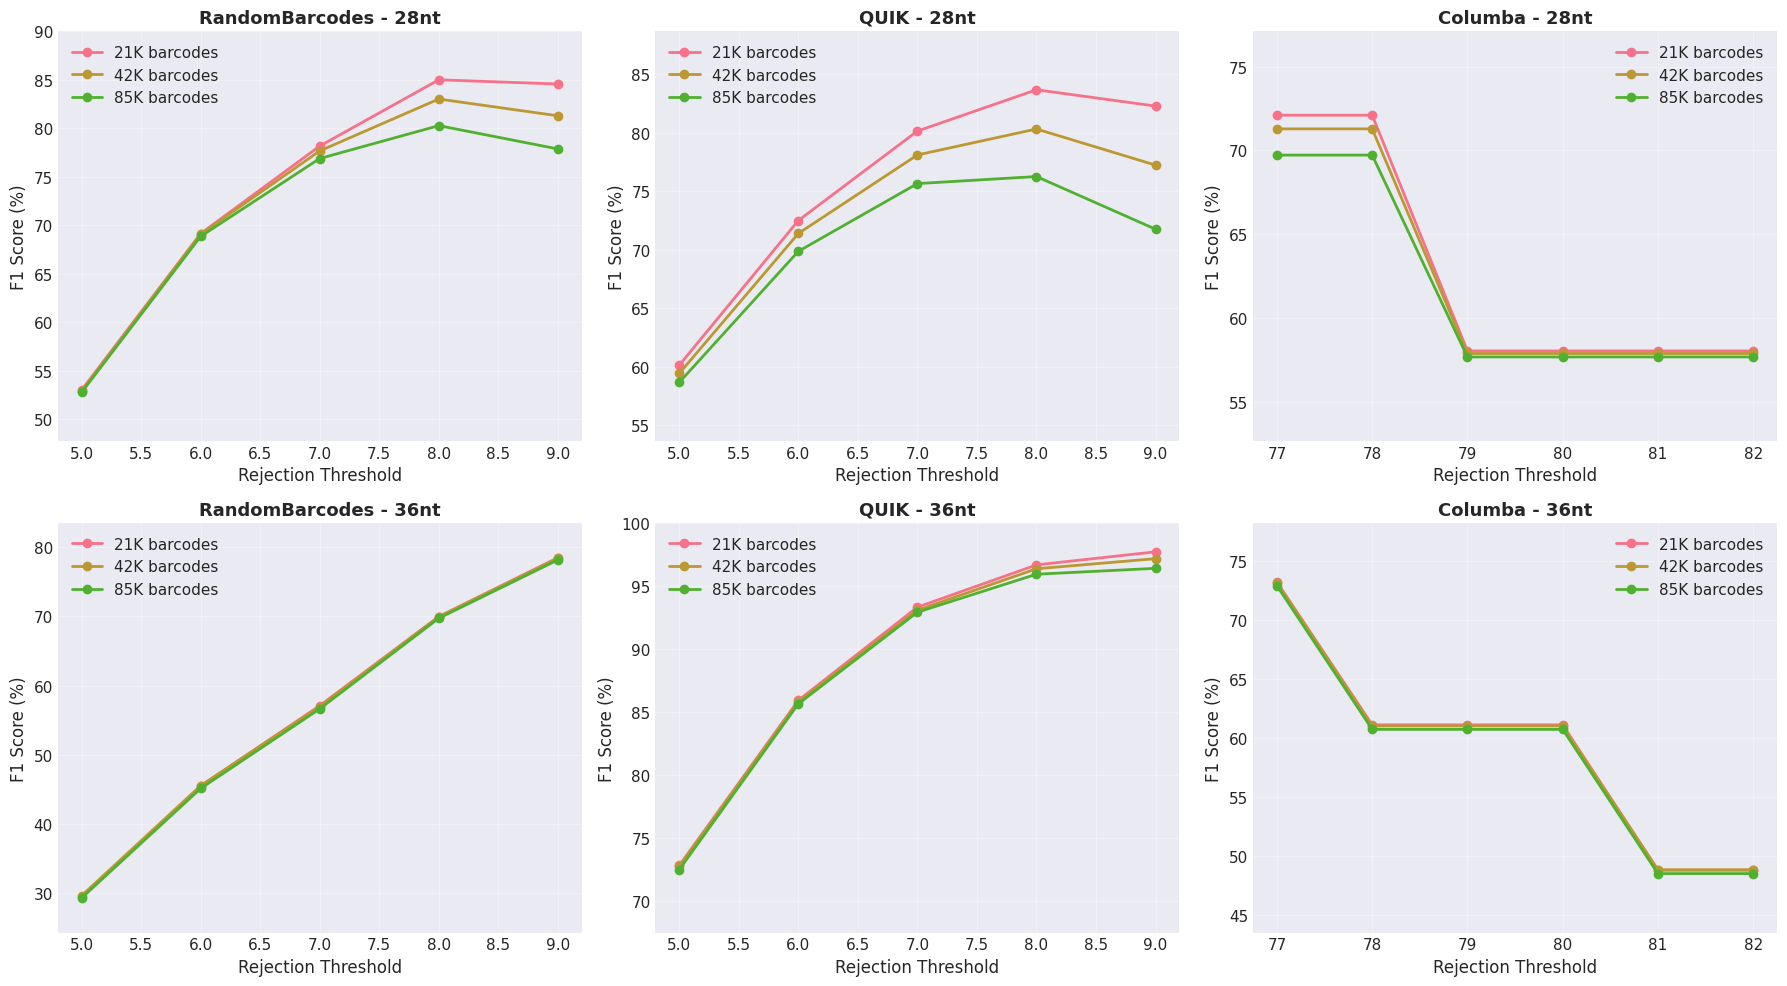

Figure saved to: notebooks/figures/barcode_count_f1_vs_threshold.png


In [22]:
if len(df_all) > 0 and 'f1_score' in df_all.columns:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    for i, barcode_length in enumerate(BARCODE_LENGTHS):
        for j, tool_name in enumerate(['RandomBarcodes', 'QUIK', 'Columba']):
            ax = axes[i, j]
            
            df_subset = df_all[(df_all['tool'] == tool_name) & (df_all['barcode_length'] == barcode_length)]
            
            for barcode_count in BARCODE_COUNTS:
                df_plot = df_subset[df_subset['barcode_count'] == barcode_count]
                if len(df_plot) > 0:
                    count_label = f"{barcode_count//1000}K"
                    ax.plot(df_plot['threshold'], df_plot['f1_score'], 
                           marker='o', label=f'{count_label} barcodes', linewidth=2)
            
            ax.set_xlabel('Rejection Threshold', fontsize=12)
            ax.set_ylabel('F1 Score (%)', fontsize=12)
            ax.set_title(f'{tool_name} - {barcode_length}nt', fontsize=13, fontweight='bold')
            ax.legend()
            ax.grid(True, alpha=0.3)
            if len(df_subset) > 0:
                ax.set_ylim([max(0, df_subset['f1_score'].min() - 5), min(100, df_subset['f1_score'].max() + 5)])
    
    plt.tight_layout()
    plt.savefig('/user/gent/446/vsc44685/ScratchVO_dir/barcalling_review/notebooks/figures/barcode_count_f1_vs_threshold.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Figure saved to: notebooks/figures/barcode_count_f1_vs_threshold.png")

### 3.4 Precision-Recall Curves

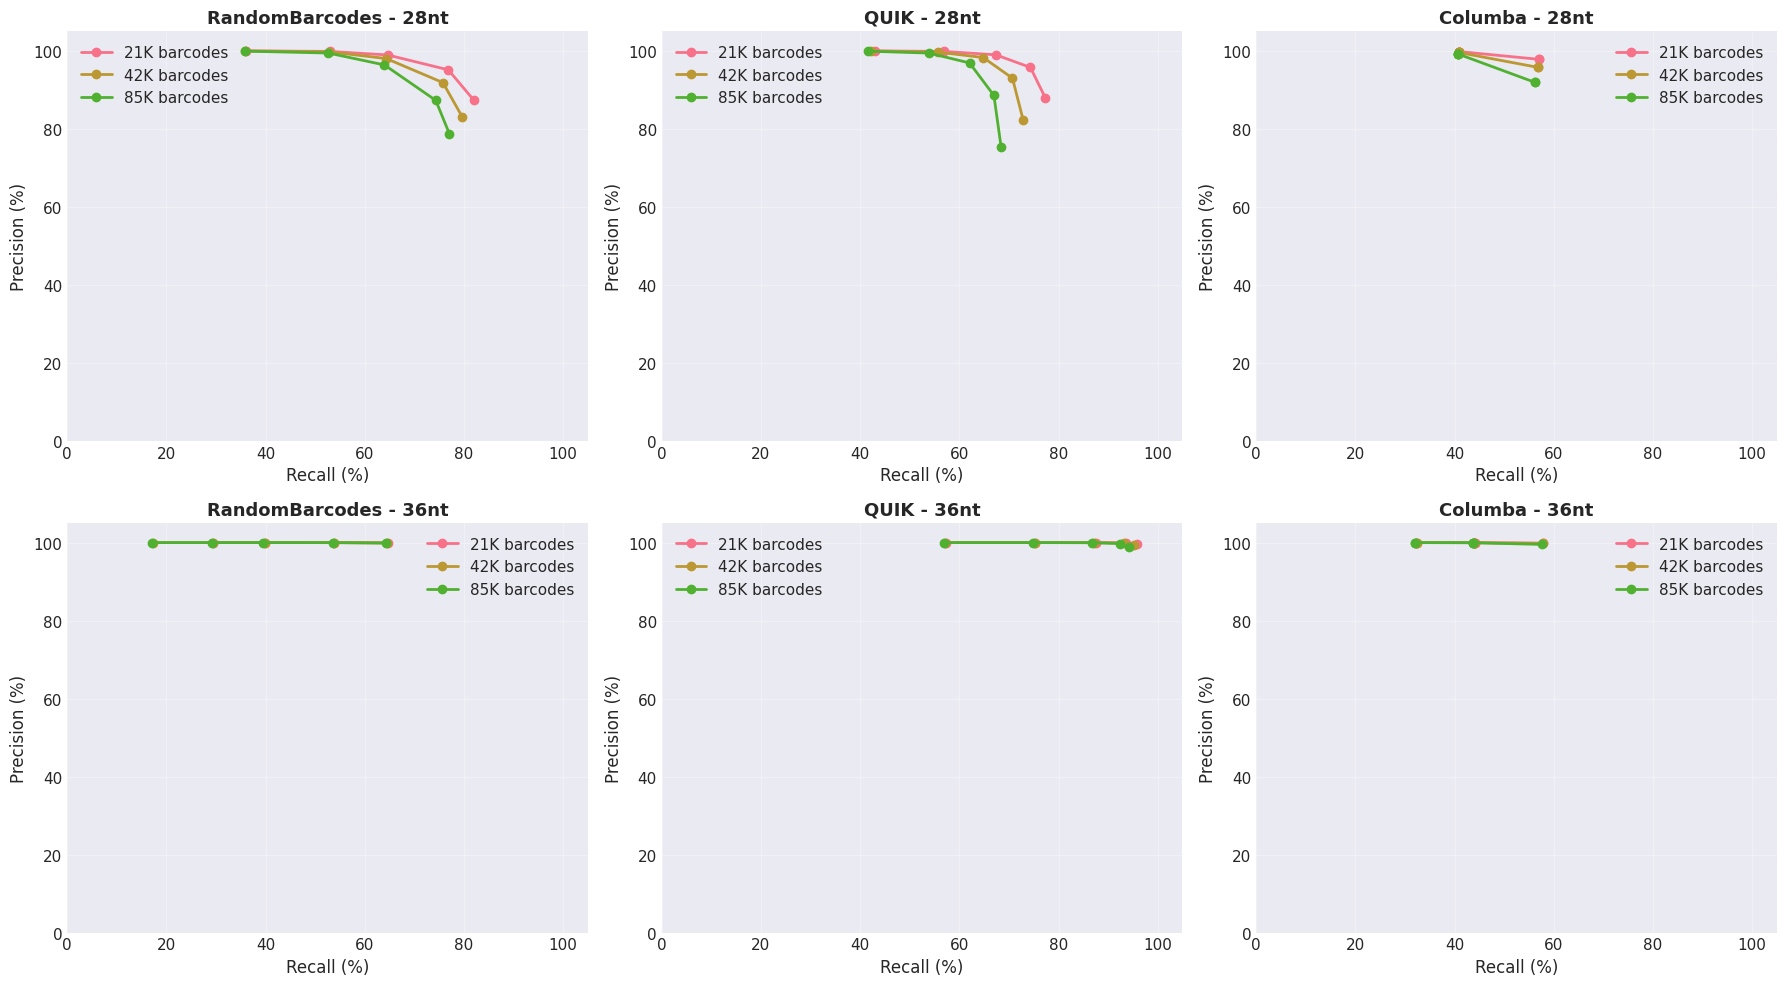

Figure saved to: notebooks/figures/barcode_count_precision_recall_curves.png


In [10]:
if len(df_all) > 0 and 'precision' in df_all.columns and 'recall' in df_all.columns:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    for i, barcode_length in enumerate(BARCODE_LENGTHS):
        for j, tool_name in enumerate(['RandomBarcodes', 'QUIK', 'Columba']):
            ax = axes[i, j]
            
            df_subset = df_all[(df_all['tool'] == tool_name) & (df_all['barcode_length'] == barcode_length)]
            
            for barcode_count in BARCODE_COUNTS:
                df_plot = df_subset[df_subset['barcode_count'] == barcode_count].sort_values('recall')
                if len(df_plot) > 0:
                    count_label = f"{barcode_count//1000}K"
                    ax.plot(df_plot['recall'], df_plot['precision'], 
                           marker='o', label=f'{count_label} barcodes', linewidth=2)
            
            ax.set_xlabel('Recall (%)', fontsize=12)
            ax.set_ylabel('Precision (%)', fontsize=12)
            ax.set_title(f'{tool_name} - {barcode_length}nt', fontsize=13, fontweight='bold')
            ax.legend()
            ax.grid(True, alpha=0.3)
            ax.set_xlim([0, 105])
            ax.set_ylim([0, 105])
    
    plt.tight_layout()
    plt.savefig('/user/gent/446/vsc44685/ScratchVO_dir/barcalling_review/notebooks/figures/barcode_count_precision_recall_curves.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Figure saved to: notebooks/figures/barcode_count_precision_recall_curves.png")

In [10]:
df_all[(df_all['tool'] == 'RandomBarcodes') & (df_all['barcode_length'] == 36)]

,tool,sample_id,identity_threshold,nthresh,ntriage,rejection_threshold,strategy,total_reads,correct,incorrect,...,precision,recall,accuracy,f1_score,barcode_count,barcode_length,threshold,tool_key,assigned,total_processed
5,RandomBarcodes,RB_t100_n6,NaN,6.0,100.0,NaN,NaN,200000.0,58837.0,1.0,...,99.998300,29.4185,29.4185,45.462413,21000,36,6.0,randombarcodes,NaN,NaN
6,RandomBarcodes,RB_t100_n7,NaN,7.0,100.0,NaN,NaN,200000.0,79899.0,2.0,...,99.997497,39.9495,39.9495,57.090900,21000,36,7.0,randombarcodes,NaN,NaN
7,RandomBarcodes,RB_t100_n8,NaN,8.0,100.0,NaN,NaN,200000.0,107642.0,8.0,...,99.992569,53.8210,53.8210,69.976922,21000,36,8.0,randombarcodes,NaN,NaN
8,RandomBarcodes,RB_t100_n9,NaN,9.0,100.0,NaN,NaN,200000.0,129227.0,65.0,...,99.949726,64.6135,64.6135,78.487786,21000,36,9.0,randombarcodes,NaN,NaN
14,RandomBarcodes,RB_42K_36nt_t100_n5,NaN,NaN,NaN,NaN,NaN,200000.0,34754.0,0.0,...,100.000000,17.3770,17.3770,29.608867,42000,36,5.0,randombarcodes,34754.0,NaN
15,RandomBarcodes,RB_42K_36nt_t100_n6,NaN,NaN,NaN,NaN,NaN,200000.0,58935.0,0.0,...,100.000000,29.4675,29.4675,45.521077,42000,36,6.0,randombarcodes,58935.0,NaN
16,RandomBarcodes,RB_42K_36nt_t100_n7,NaN,NaN,NaN,NaN,NaN,200000.0,79626.0,0.0,...,100.000000,39.8130,39.8130,56.951786,42000,36,7.0,randombarcodes,79626.0,NaN
17,RandomBarcodes,RB_42K_36nt_t100_n8,NaN,NaN,NaN,NaN,NaN,200000.0,107536.0,11.0,...,99.989800,53.7680,53.7680,69.931432,42000,36,8.0,randombarcodes,107547.0,NaN
18,RandomBarcodes,RB_42K_36nt_t100_n9,NaN,NaN,NaN,NaN,NaN,200000.0,128955.0,98.0,...,99.924100,64.4775,64.4775,78.379482,42000,36,9.0,randombarcodes,129053.0,NaN
24,RandomBarcodes,RB_85K_36nt_t100_n5,NaN,NaN,NaN,NaN,NaN,200000.0,34295.0,0.0,...,100.000000,17.1475,17.1475,29.275059,85000,36,5.0,randombarcodes,34295.0,NaN


### 3.5 Effect of Barcode Count on Accuracy

This figure shows how precision and recall are affected by barcode library size (21K, 42K, 85K barcodes).
Each point represents the configuration with **precision ≥ 99.5%** and the **highest recall** for that tool/barcode count combination.

Available tools in dataset: ['RandomBarcodes' 'QUIK' 'Columba']
Available barcode counts: [21000, 42000, 85000]
Available barcode lengths: [28, 36]

Total rows in df_all: 95
Selected for RandomBarcodes 21000 28nt: P=99.99%, R=36.07%, thr=5.0, F1=53.01%
Selected for RandomBarcodes 21000 36nt: P=99.95%, R=64.61%, thr=9.0, F1=78.49%
Selected for RandomBarcodes 42000 28nt: P=99.98%, R=35.93%, thr=5.0, F1=52.86%
Selected for RandomBarcodes 42000 36nt: P=99.92%, R=64.48%, thr=9.0, F1=78.38%
Selected for RandomBarcodes 85000 28nt: P=99.92%, R=35.85%, thr=5.0, F1=52.77%
Selected for RandomBarcodes 85000 36nt: P=99.99%, R=53.53%, thr=8.0, F1=69.73%
Selected for QUIK 21000 28nt: P=99.99%, R=42.98%, thr=5.0, F1=60.12%
Selected for QUIK 21000 36nt: P=99.94%, R=93.63%, thr=8.0, F1=96.68%
Selected for QUIK 42000 28nt: P=99.96%, R=42.27%, thr=5.0, F1=59.42%
Selected for QUIK 42000 36nt: P=99.98%, R=87.08%, thr=7.0, F1=93.08%
Selected for QUIK 85000 28nt: P=99.91%, R=41.51%, thr=5.0, F1=58.65%
Selecte

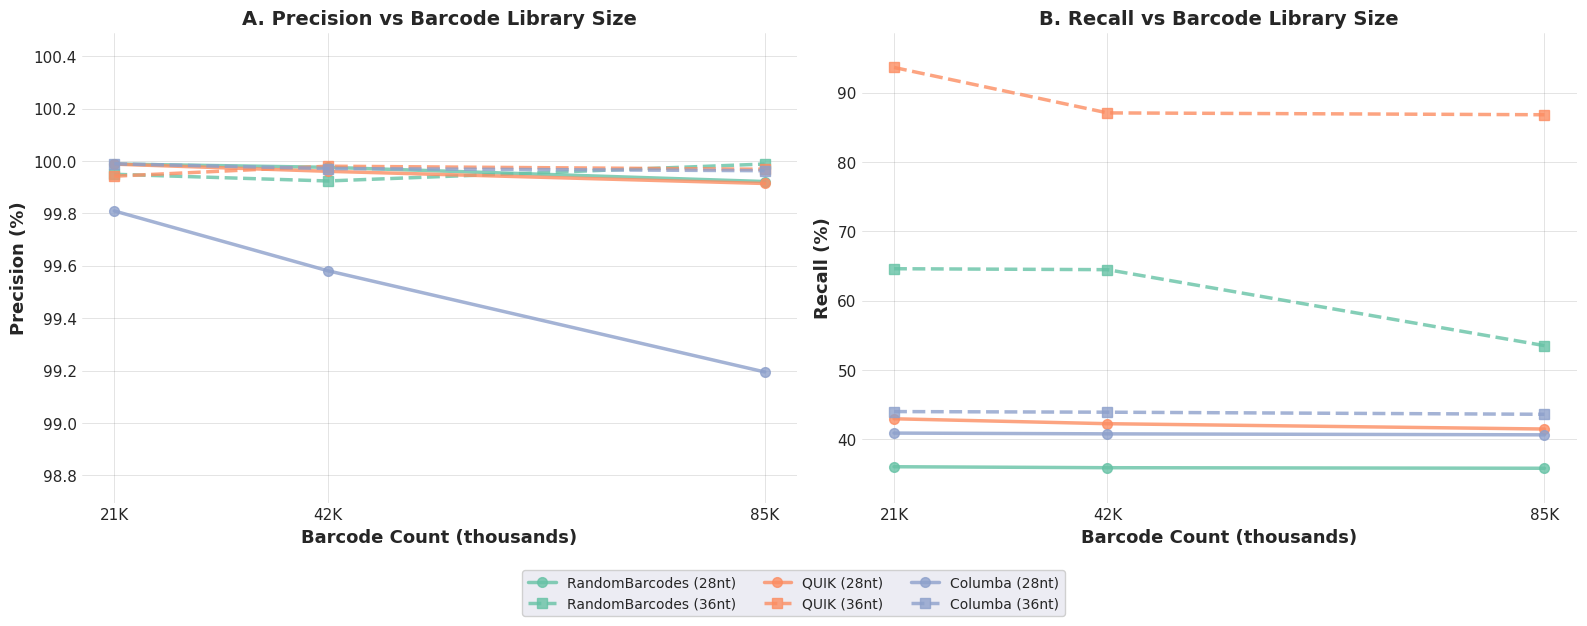


✓ Figure saved to: notebooks/figures/barcode_count_effect_on_accuracy.pdf

KEY FINDINGS: Barcode Count Effect on Accuracy

RandomBarcodes:
  28nt (21K→85K): Precision 99.99%→99.92% (-0.07%), Recall 36.07%→35.85% (-0.22%)
  36nt (21K→85K): Precision 99.95%→99.99% (+0.04%), Recall 64.61%→53.53% (-11.09%)

QUIK:
  28nt (21K→85K): Precision 99.99%→99.91% (-0.07%), Recall 42.98%→41.51% (-1.48%)
  36nt (21K→85K): Precision 99.94%→99.97% (+0.03%), Recall 93.63%→86.81% (-6.82%)

Columba:
  28nt (21K→85K): Precision 99.81%→99.20% (-0.61%), Recall 40.92%→40.67% (-0.25%)
  36nt (21K→85K): Precision 99.99%→99.96% (-0.03%), Recall 44.02%→43.63% (-0.39%)



In [11]:
if len(df_all) > 0 and 'precision' in df_all.columns and 'recall' in df_all.columns:
    # Debug: Check available tools and configurations
    print("Available tools in dataset:", df_all['tool'].unique())
    print("Available barcode counts:", sorted(df_all['barcode_count'].unique()))
    print("Available barcode lengths:", sorted(df_all['barcode_length'].unique()))
    print(f"\nTotal rows in df_all: {len(df_all)}")
    
    # Select best performance per tool/count/length using:
    #   precision >= 99.5% (hard constraint) and, among those, highest recall
    # If no configuration meets the precision constraint, fall back to highest precision (then recall).
    PRECISION_MIN = 99.9
    best_performances = []
    
    # Get unique values from actual data
    available_tools = df_all['tool'].unique()
    available_counts = sorted(df_all['barcode_count'].unique())
    available_lengths = sorted(df_all['barcode_length'].unique())
    
    for tool_name in available_tools:
        for barcode_count in available_counts:
            for barcode_length in available_lengths:
                df_subset = df_all[
                    (df_all['tool'] == tool_name) & 
                    (df_all['barcode_count'] == barcode_count) & 
                    (df_all['barcode_length'] == barcode_length)
                ]
                
                if len(df_subset) > 0:
                    eligible = df_subset[df_subset['precision'] >= PRECISION_MIN]
                    used_fallback = False
                    if len(eligible) > 0:
                        best_idx = eligible['recall'].idxmax()
                        best_row = eligible.loc[best_idx]
                    else:
                        used_fallback = True
                        best_row = df_subset.sort_values(['precision', 'recall'], ascending=[False, False]).iloc[0]
                    
                    best_performances.append({
                        'tool': tool_name,
                        'barcode_count': barcode_count,
                        'barcode_length': barcode_length,
                        'precision': float(best_row['precision']),
                        'recall': float(best_row['recall']),
                        'f1_score': float(best_row.get('f1_score', np.nan)),
                        'threshold': float(best_row['threshold'])
                    })

                    suffix = " (fallback: max precision)" if used_fallback else ""
                    print(
                        f"Selected for {tool_name} {barcode_count} {barcode_length}nt: "
                        f"P={best_row['precision']:.2f}%, R={best_row['recall']:.2f}%, "
                        f"thr={best_row['threshold']}, F1={best_row.get('f1_score', np.nan):.2f}%" + suffix
                    )
    
    df_best = pd.DataFrame(best_performances)
    print(f"\nCreated df_best with {len(df_best)} rows")
    
    # Only proceed with plotting if we have data
    if len(df_best) == 0:
        print("\n⚠️ WARNING: No data found for plotting. Check data loading.")
    else:
        # Create figure with 2 panels
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Set white background
        fig.patch.set_facecolor('white')
        
        # Colors for tools (Set2 palette)
        tool_order = ['RandomBarcodes', 'QUIK', 'Columba']
        tool_palette = sns.color_palette("Set2", n_colors=len(tool_order))
        tool_colors = dict(zip(tool_order, tool_palette))
        
        # Define markers for barcode lengths
        length_markers = {
            28: 'o',  # circle
            36: 's'   # square
        }
        
        # Use actual data for labels
        unique_counts = sorted(df_best['barcode_count'].unique())
        barcode_count_labels = [f'{int(c//1000)}K' for c in unique_counts]
        
        # Store handles and labels for shared legend
        handles = []
        labels = []
        
        # Panel A: Precision vs Barcode Count
        ax = axes[0]
        ax.set_facecolor('white')
        
        for tool_name in df_best['tool'].unique():
            for barcode_length in sorted(df_best['barcode_length'].unique()):
                df_plot = df_best[
                    (df_best['tool'] == tool_name) & 
                    (df_best['barcode_length'] == barcode_length)
                ].sort_values('barcode_count')
                
                if len(df_plot) > 0:
                    label = f'{tool_name} ({int(barcode_length)}nt)'
                    line, = ax.plot(df_plot['barcode_count']/1000, df_plot['precision'],
                           marker=length_markers.get(barcode_length, 'o'),
                           markersize=7,
                           color=tool_colors.get(tool_name, '#333333'),
                           linestyle='-' if barcode_length == 28 else '--',
                           linewidth=2.5,
                           alpha=0.8,
                           label=label)
                    # Collect handles and labels only once (from Panel A)
                    if ax == axes[0]:
                        handles.append(line)
                        labels.append(label)
        
        # Add horizontal reference line at 99.9%
        # ref_line = ax.axhline(y=99.9, color='red', linestyle=':', linewidth=2, alpha=0.7, label='Target: 99.9%')
        # handles.append(ref_line)
        # labels.append('Target: 99.9%')
        
        ax.set_xlabel('Barcode Count (thousands)', fontsize=13, fontweight='bold')
        ax.set_ylabel('Precision (%)', fontsize=13, fontweight='bold')
        ax.set_title('A. Precision vs Barcode Library Size', fontsize=14, fontweight='bold')
        ax.set_xticks([c/1000 for c in unique_counts])
        ax.set_xticklabels(barcode_count_labels)
        ax.grid(True, alpha=0.3, color='gray', linestyle='-', linewidth=0.5)
        # Dynamic y-axis limits based on data
        prec_min = df_best['precision'].min()
        prec_max = df_best['precision'].max()
        ax.set_ylim([max(0, prec_min - 0.5), min(105, prec_max + 0.5)])
        
        # Panel B: Recall vs Barcode Count
        ax = axes[1]
        ax.set_facecolor('white')
        
        for tool_name in df_best['tool'].unique():
            for barcode_length in sorted(df_best['barcode_length'].unique()):
                df_plot = df_best[
                    (df_best['tool'] == tool_name) & 
                    (df_best['barcode_length'] == barcode_length)
                ].sort_values('barcode_count')
                
                if len(df_plot) > 0:
                    label = f'{tool_name} ({int(barcode_length)}nt)'
                    ax.plot(df_plot['barcode_count']/1000, df_plot['recall'],
                           marker=length_markers.get(barcode_length, 'o'),
                           markersize=7,
                           color=tool_colors.get(tool_name, '#333333'),
                           linestyle='-' if barcode_length == 28 else '--',
                           linewidth=2.5,
                           alpha=0.8,
                           label=label)
        
        ax.set_xlabel('Barcode Count (thousands)', fontsize=13, fontweight='bold')
        ax.set_ylabel('Recall (%)', fontsize=13, fontweight='bold')
        ax.set_title('B. Recall vs Barcode Library Size', fontsize=14, fontweight='bold')
        ax.set_xticks([c/1000 for c in unique_counts])
        ax.set_xticklabels(barcode_count_labels)
        ax.grid(True, alpha=0.3, color='gray', linestyle='-', linewidth=0.5)
        # Dynamic y-axis limits based on data
        rec_min = df_best['recall'].min()
        rec_max = df_best['recall'].max()
        ax.set_ylim([max(0, rec_min - 5), min(105, rec_max + 5)])
        
        # Create single legend for both panels, positioned at the bottom center
        fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05),
                  ncol=3, fontsize=10, framealpha=0.9, frameon=True)
        
        plt.tight_layout()
        # Adjust layout to make room for legend at bottom
        plt.subplots_adjust(bottom=0.15)
        plt.savefig('/user/gent/446/vsc44685/ScratchVO_dir/barcalling_review/notebooks/figures/barcode_count_effect_on_accuracy.pdf', 
                    dpi=300, bbox_inches='tight')
        plt.show()
        
        print("\n✓ Figure saved to: notebooks/figures/barcode_count_effect_on_accuracy.pdf")
        
        # Print key findings
        print("\n" + "="*80)
        print("KEY FINDINGS: Barcode Count Effect on Accuracy")
        print("="*80)
        
        for tool_name in df_best['tool'].unique():
            print(f"\n{tool_name}:")
            for barcode_length in sorted(df_best['barcode_length'].unique()):
                df_tool = df_best[
                    (df_best['tool'] == tool_name) & 
                    (df_best['barcode_length'] == barcode_length)
                ].sort_values('barcode_count')
                
                if len(df_tool) >= 2:
                    first_prec = df_tool.iloc[0]['precision']
                    last_prec = df_tool.iloc[-1]['precision']
                    first_rec = df_tool.iloc[0]['recall']
                    last_rec = df_tool.iloc[-1]['recall']
                    first_count = int(df_tool.iloc[0]['barcode_count'])
                    last_count = int(df_tool.iloc[-1]['barcode_count'])
                    
                    prec_change = last_prec - first_prec
                    rec_change = last_rec - first_rec
                    
                    print(f"  {int(barcode_length)}nt ({first_count//1000}K→{last_count//1000}K): "
                          f"Precision {first_prec:.2f}%→{last_prec:.2f}% ({prec_change:+.2f}%), "
                          f"Recall {first_rec:.2f}%→{last_rec:.2f}% ({rec_change:+.2f}%)")
                elif len(df_tool) == 1:
                    print(f"  {int(barcode_length)}nt: Only one data point available")
        
        print("\n" + "="*80)
else:
    print("⚠️ Cannot create plot: Missing required columns (precision, recall) or empty dataframe")

## 4. Optimal Threshold Analysis

### 4.1 Find Optimal Thresholds for Each Configuration

We define "optimal" as the threshold that maximizes F1 score.

In [58]:
if len(df_all) > 0 and 'f1_score' in df_all.columns:
    # Find optimal threshold for each tool/count/length combination
    optimal_thresholds = []
    
    for tool_name in ['RandomBarcodes', 'QUIK', 'Columba']:
        for barcode_count in BARCODE_COUNTS:
            for barcode_length in BARCODE_LENGTHS:
                df_subset = df_all[
                    (df_all['tool'] == tool_name) & 
                    (df_all['barcode_count'] == barcode_count) & 
                    (df_all['barcode_length'] == barcode_length)
                ]
                
                if len(df_subset) > 0:
                    # Find row with maximum F1 score
                    best_row = df_subset.loc[df_subset['f1_score'].idxmax()]
                    
                    optimal_thresholds.append({
                        'tool': tool_name,
                        'barcode_count': barcode_count,
                        'barcode_length': barcode_length,
                        'optimal_threshold': best_row['threshold'],
                        'precision': best_row['precision'],
                        'recall': best_row['recall'],
                        'f1_score': best_row['f1_score']
                    })
    
    df_optimal = pd.DataFrame(optimal_thresholds)
    
    print("Optimal Thresholds (maximizing F1 score):\n")
    display(df_optimal)
    
    # Save to CSV
    output_file = '/user/gent/446/vsc44685/ScratchVO_dir/barcalling_review/notebooks/optimal_thresholds_by_barcode_count.csv'
    df_optimal.to_csv(output_file, index=False)
    print(f"\nSaved optimal thresholds to: {output_file}")

Optimal Thresholds (maximizing F1 score):



,tool,barcode_count,barcode_length,optimal_threshold,precision,recall,f1_score
0,RandomBarcodes,21000,28,8.0,95.130604,76.8270,85.004661
1,RandomBarcodes,21000,36,9.0,99.949726,64.6135,78.487786
2,RandomBarcodes,42000,28,8.0,91.856100,75.7395,83.022885
3,RandomBarcodes,42000,36,9.0,99.924100,64.4775,78.379482
4,RandomBarcodes,85000,28,8.0,87.303000,74.3010,80.278956
5,RandomBarcodes,85000,36,9.0,99.876300,64.2035,78.162065
6,QUIK,21000,28,8.0,95.747400,74.3325,83.691766
7,QUIK,21000,36,9.0,99.633700,95.8775,97.719518
8,QUIK,42000,28,8.0,92.991200,70.7105,80.334587
9,QUIK,42000,36,9.0,99.312000,95.1300,97.176027



Saved optimal thresholds to: /user/gent/446/vsc44685/ScratchVO_dir/barcalling_review/notebooks/optimal_thresholds_by_barcode_count.csv


### 4.2 Visualize Optimal Threshold Trends

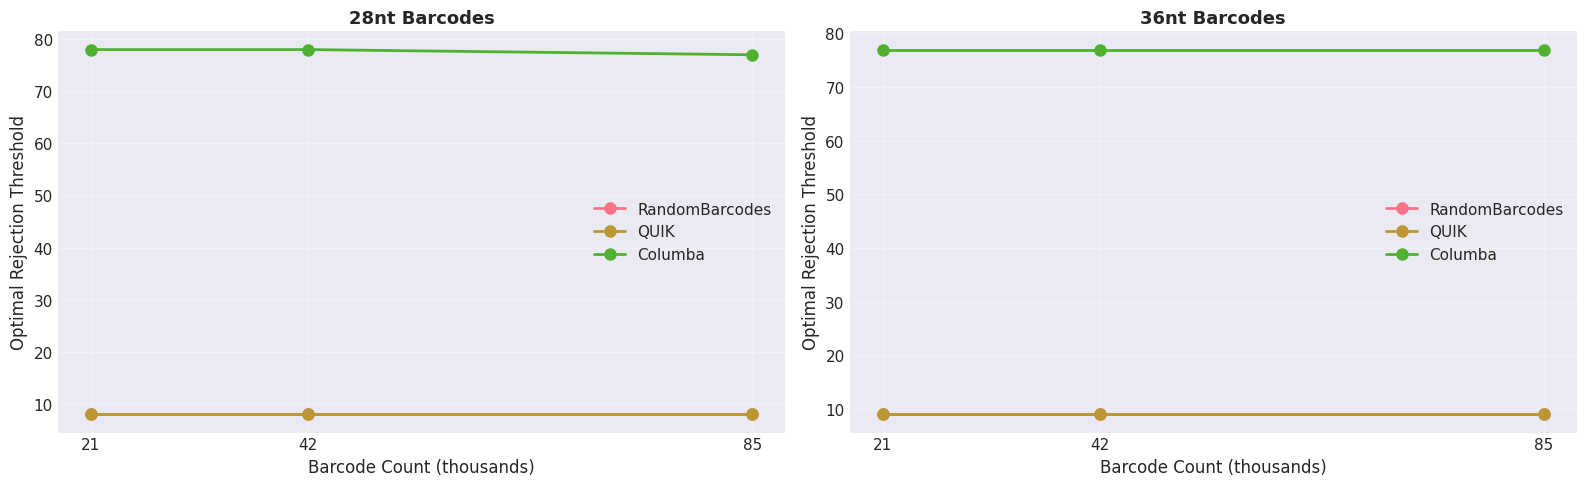

Figure saved to: notebooks/figures/optimal_threshold_trends.png


In [59]:
if len(df_all) > 0 and 'optimal_thresholds' in locals() and len(optimal_thresholds) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    for i, barcode_length in enumerate(BARCODE_LENGTHS):
        ax = axes[i]
        
        for tool_name in ['RandomBarcodes', 'QUIK', 'Columba']:
            df_plot = df_optimal[
                (df_optimal['tool'] == tool_name) & 
                (df_optimal['barcode_length'] == barcode_length)
            ].sort_values('barcode_count')
            
            if len(df_plot) > 0:
                ax.plot(df_plot['barcode_count']/1000, df_plot['optimal_threshold'], 
                       marker='o', label=tool_name, linewidth=2, markersize=8)
        
        ax.set_xlabel('Barcode Count (thousands)', fontsize=12)
        ax.set_ylabel('Optimal Rejection Threshold', fontsize=12)
        ax.set_title(f'{barcode_length}nt Barcodes', fontsize=13, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_xticks([21, 42, 85])
    
    plt.tight_layout()
    plt.savefig('/user/gent/446/vsc44685/ScratchVO_dir/barcalling_review/notebooks/figures/optimal_threshold_trends.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Figure saved to: notebooks/figures/optimal_threshold_trends.png")

### 4.3 Heatmap: Optimal F1 Scores

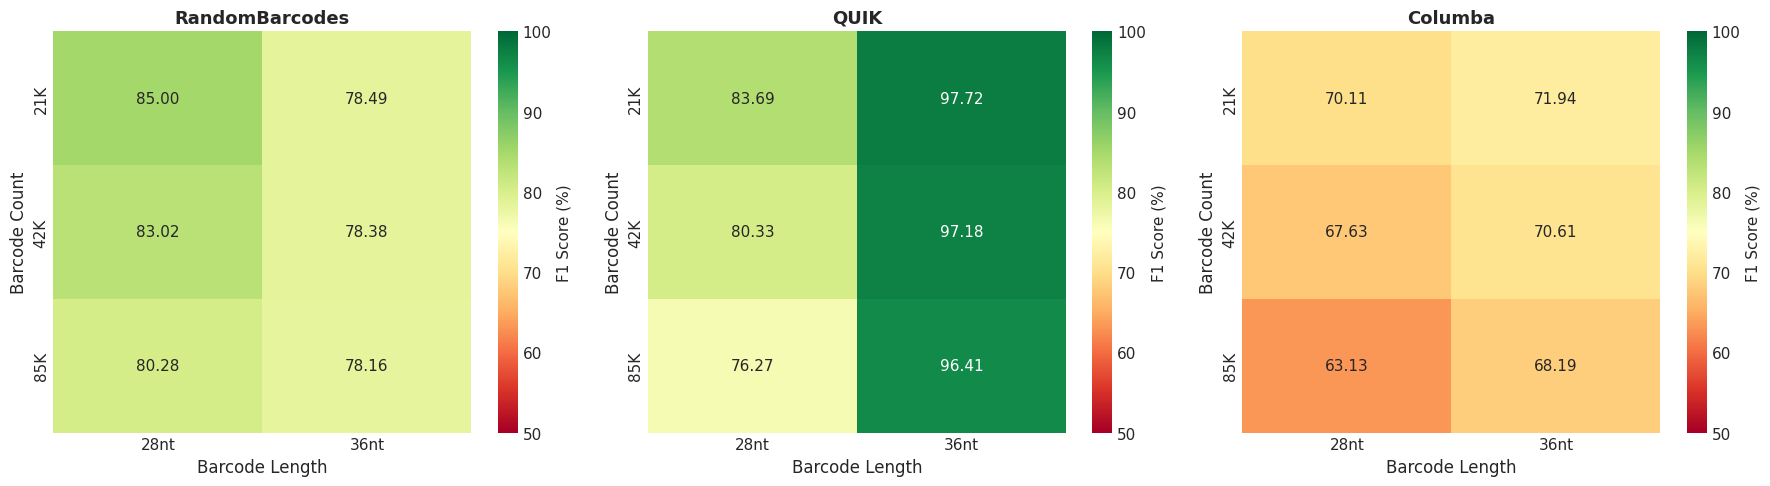

Figure saved to: notebooks/figures/optimal_f1_heatmap.png


In [55]:
if len(df_all) > 0 and 'optimal_thresholds' in locals() and len(optimal_thresholds) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for j, tool_name in enumerate(['RandomBarcodes', 'QUIK', 'Columba']):
        ax = axes[j]
        
        # Pivot data for heatmap
        df_plot = df_optimal[df_optimal['tool'] == tool_name].copy()
        df_plot['count_label'] = df_plot['barcode_count'].apply(lambda x: f"{x//1000}K")
        df_plot['length_label'] = df_plot['barcode_length'].apply(lambda x: f"{x}nt")
        
        pivot = df_plot.pivot(index='count_label', columns='length_label', values='f1_score')
        
        # Reorder rows
        pivot = pivot.reindex(['21K', '42K', '85K'])
        
        sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', vmin=50, vmax=100,
                   ax=ax, cbar_kws={'label': 'F1 Score (%)'})
        ax.set_title(f'{tool_name}', fontsize=13, fontweight='bold')
        ax.set_xlabel('Barcode Length', fontsize=12)
        ax.set_ylabel('Barcode Count', fontsize=12)
    
    plt.tight_layout()
    plt.savefig('/user/gent/446/vsc44685/ScratchVO_dir/barcalling_review/notebooks/figures/optimal_f1_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Figure saved to: notebooks/figures/optimal_f1_heatmap.png")

## 5. Comparative Analysis

### 5.1 Tool Comparison at Optimal Thresholds

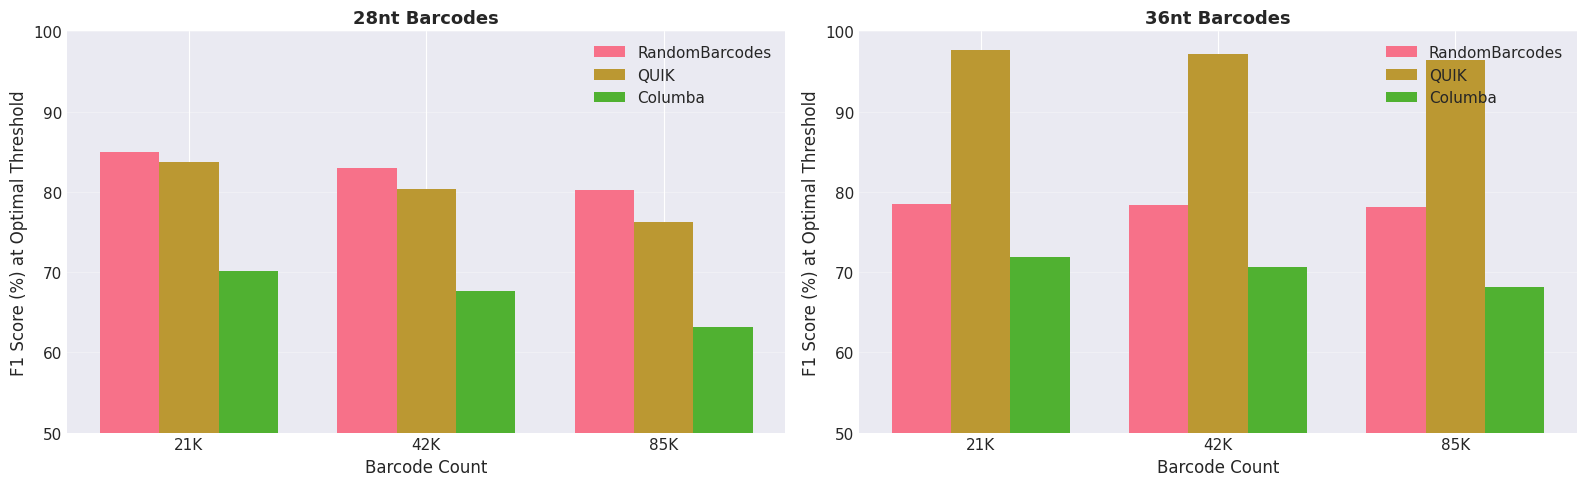

Figure saved to: notebooks/figures/tool_comparison_optimal.png


In [56]:
if len(df_all) > 0 and 'optimal_thresholds' in locals() and len(optimal_thresholds) > 0:
    # Create grouped bar chart
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    for i, barcode_length in enumerate(BARCODE_LENGTHS):
        ax = axes[i]
        
        df_plot = df_optimal[df_optimal['barcode_length'] == barcode_length]
        
        x = np.arange(len(BARCODE_COUNTS))
        width = 0.25
        
        for j, tool_name in enumerate(['RandomBarcodes', 'QUIK', 'Columba']):
            tool_data = df_plot[df_plot['tool'] == tool_name].sort_values('barcode_count')
            if len(tool_data) > 0:
                f1_scores = tool_data['f1_score'].values
                ax.bar(x + j*width, f1_scores, width, label=tool_name)
        
        ax.set_xlabel('Barcode Count', fontsize=12)
        ax.set_ylabel('F1 Score (%) at Optimal Threshold', fontsize=12)
        ax.set_title(f'{barcode_length}nt Barcodes', fontsize=13, fontweight='bold')
        ax.set_xticks(x + width)
        ax.set_xticklabels(['21K', '42K', '85K'])
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_ylim([50, 100])
    
    plt.tight_layout()
    plt.savefig('/user/gent/446/vsc44685/ScratchVO_dir/barcalling_review/notebooks/figures/tool_comparison_optimal.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Figure saved to: notebooks/figures/tool_comparison_optimal.png")

### 5.2 Performance Degradation with Increasing Barcode Count

### 5.2 Precision Comparison at Optimal Thresholds

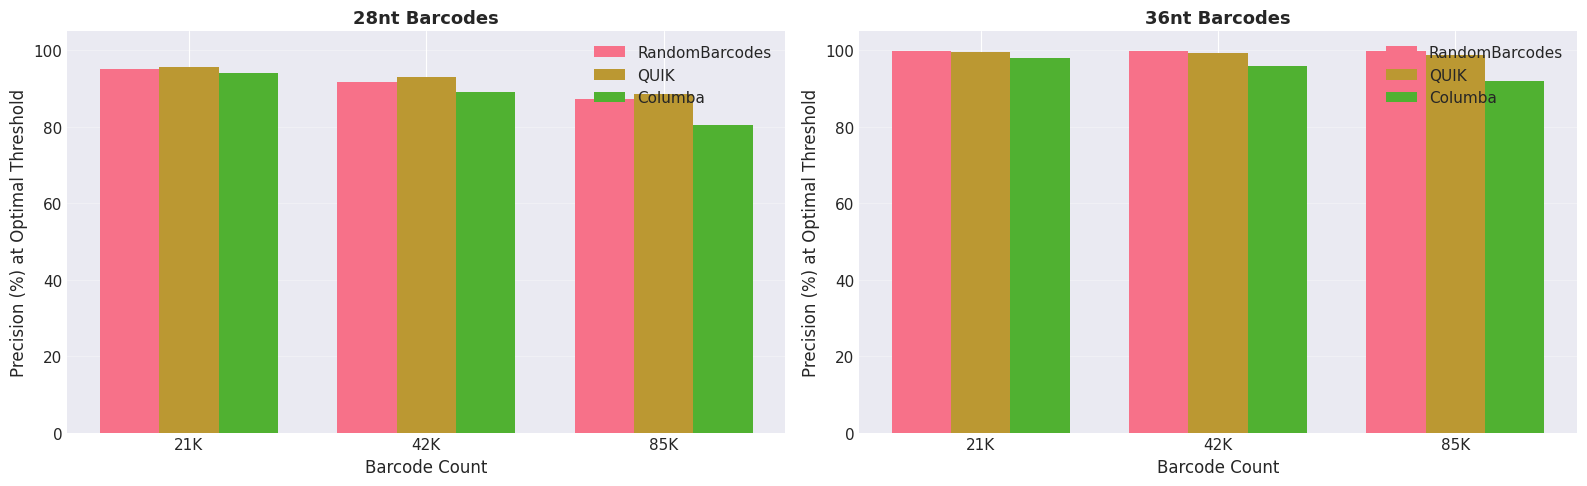

Figure saved to: notebooks/figures/precision_comparison_optimal.png


In [60]:
if len(df_all) > 0 and 'optimal_thresholds' in locals() and len(optimal_thresholds) > 0:
    # Create grouped bar chart for precision
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    for i, barcode_length in enumerate(BARCODE_LENGTHS):
        ax = axes[i]
        
        df_plot = df_optimal[df_optimal['barcode_length'] == barcode_length]
        
        x = np.arange(len(BARCODE_COUNTS))
        width = 0.25
        
        for j, tool_name in enumerate(['RandomBarcodes', 'QUIK', 'Columba']):
            tool_data = df_plot[df_plot['tool'] == tool_name].sort_values('barcode_count')
            if len(tool_data) > 0:
                precision_vals = tool_data['precision'].values
                ax.bar(x + j*width, precision_vals, width, label=tool_name)
        
        ax.set_xlabel('Barcode Count', fontsize=12)
        ax.set_ylabel('Precision (%) at Optimal Threshold', fontsize=12)
        ax.set_title(f'{barcode_length}nt Barcodes', fontsize=13, fontweight='bold')
        ax.set_xticks(x + width)
        ax.set_xticklabels(['21K', '42K', '85K'])
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_ylim([0, 105])
    
    plt.tight_layout()
    plt.savefig('/user/gent/446/vsc44685/ScratchVO_dir/barcalling_review/notebooks/figures/precision_comparison_optimal.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Figure saved to: notebooks/figures/precision_comparison_optimal.png")

### 5.3 Recall Comparison at Optimal Thresholds

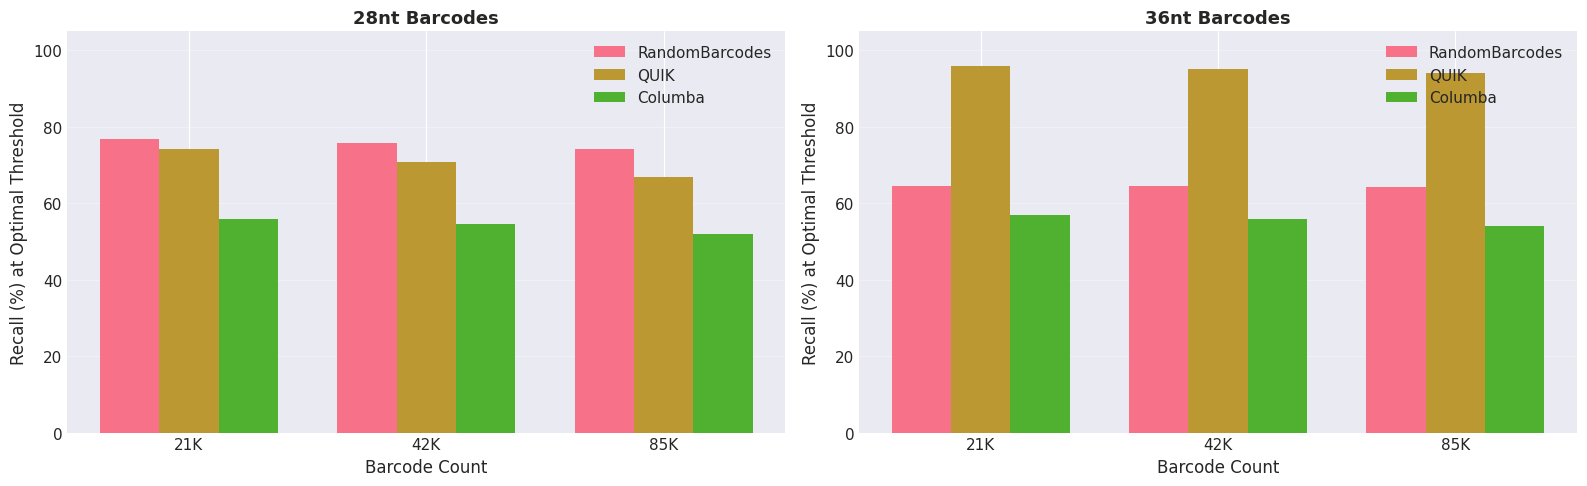

Figure saved to: notebooks/figures/recall_comparison_optimal.png


In [61]:
if len(df_all) > 0 and 'optimal_thresholds' in locals() and len(optimal_thresholds) > 0:
    # Create grouped bar chart for recall
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    for i, barcode_length in enumerate(BARCODE_LENGTHS):
        ax = axes[i]
        
        df_plot = df_optimal[df_optimal['barcode_length'] == barcode_length]
        
        x = np.arange(len(BARCODE_COUNTS))
        width = 0.25
        
        for j, tool_name in enumerate(['RandomBarcodes', 'QUIK', 'Columba']):
            tool_data = df_plot[df_plot['tool'] == tool_name].sort_values('barcode_count')
            if len(tool_data) > 0:
                recall_vals = tool_data['recall'].values
                ax.bar(x + j*width, recall_vals, width, label=tool_name)
        
        ax.set_xlabel('Barcode Count', fontsize=12)
        ax.set_ylabel('Recall (%) at Optimal Threshold', fontsize=12)
        ax.set_title(f'{barcode_length}nt Barcodes', fontsize=13, fontweight='bold')
        ax.set_xticks(x + width)
        ax.set_xticklabels(['21K', '42K', '85K'])
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_ylim([0, 105])
    
    plt.tight_layout()
    plt.savefig('/user/gent/446/vsc44685/ScratchVO_dir/barcalling_review/notebooks/figures/recall_comparison_optimal.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Figure saved to: notebooks/figures/recall_comparison_optimal.png")

### 5.4 Dual-Axis Plot: Precision & Recall vs Threshold

Precision (solid lines, left axis) and Recall (dashed lines, right axis) vs rejection threshold, color-coded by barcode count.

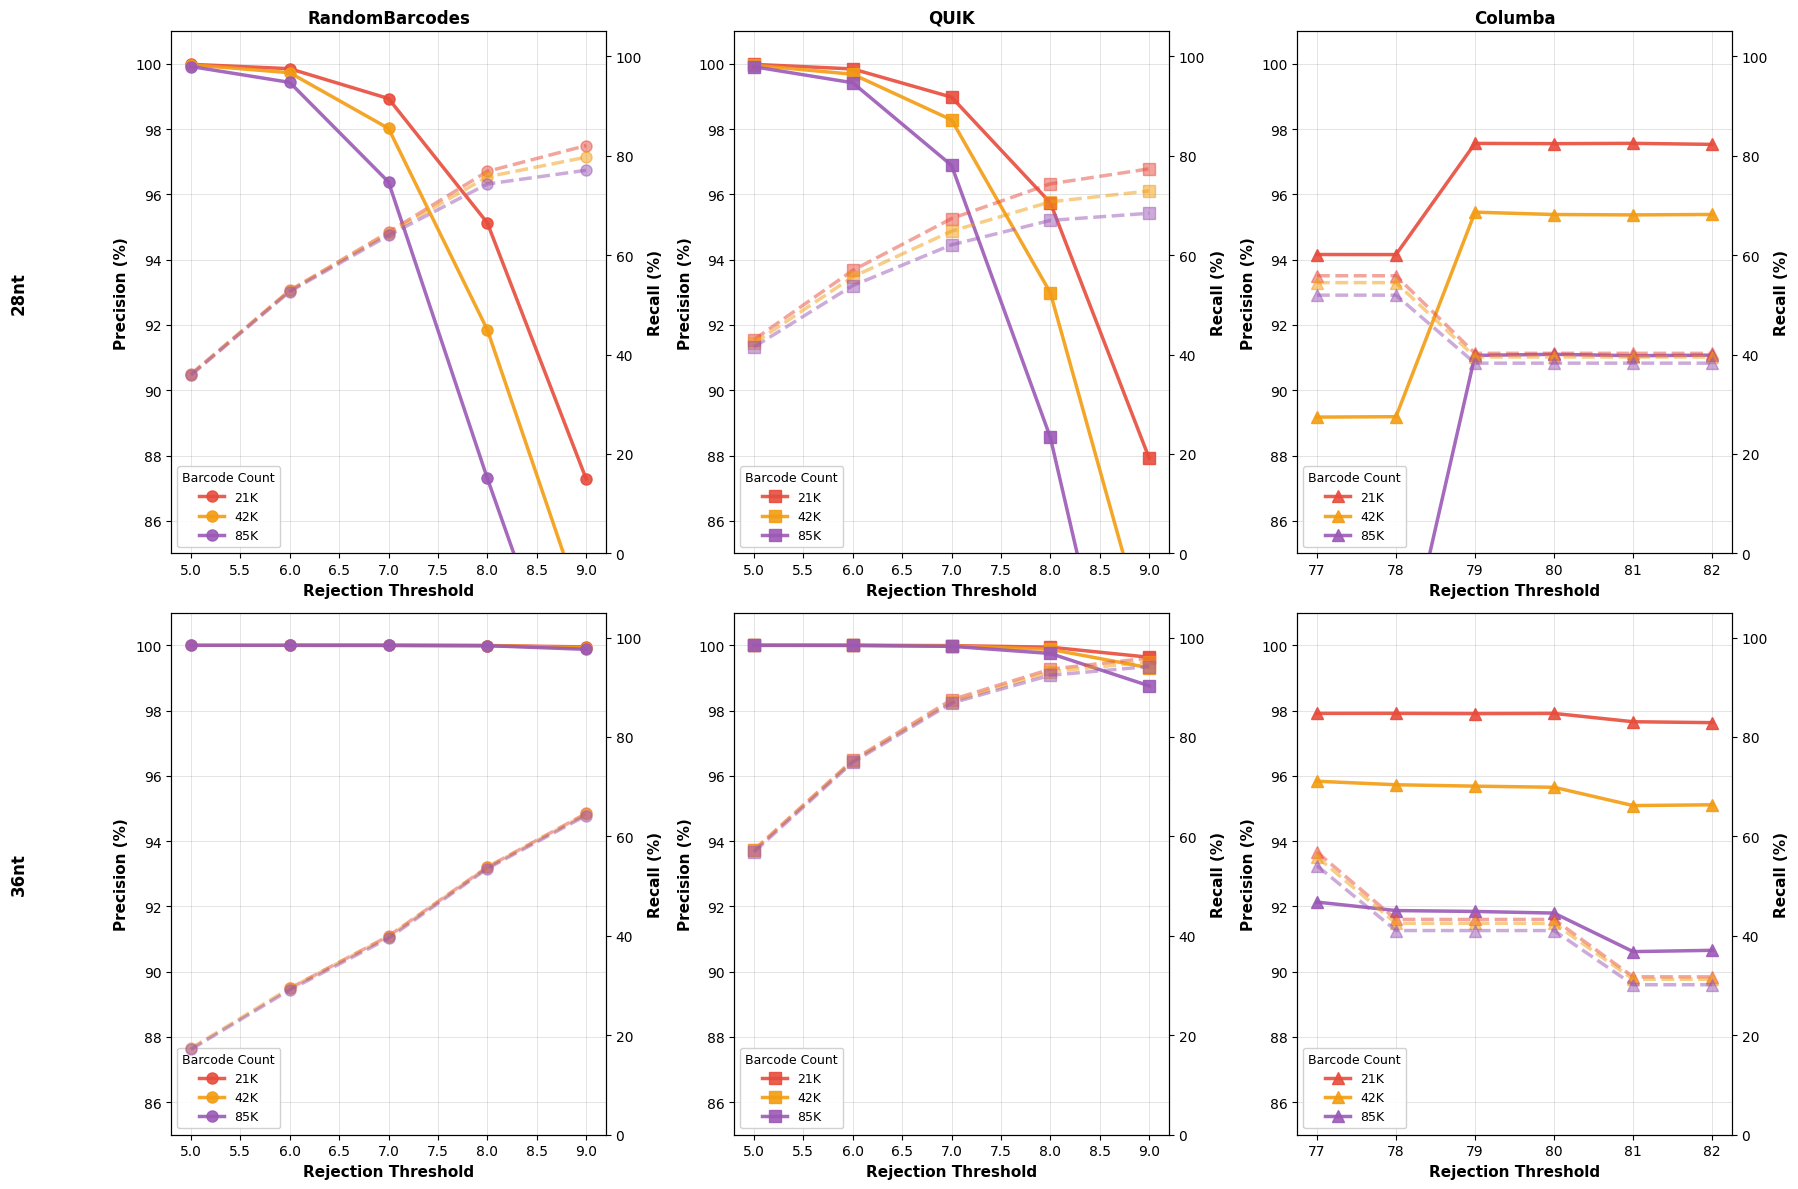

Plot saved as 'precision_recall_dual_axis.pdf'
Precision (solid line, left y-axis) and Recall (dashed line, right y-axis)
Color indicates barcode count: Red=21K, Orange=42K, Purple=85K


In [62]:
if len(df_all) > 0 and 'precision' in df_all.columns and 'recall' in df_all.columns:
    # Define color palette for barcode counts (color-coded by barcode count)
    barcode_colors = {
        21000: '#e74c3c',  # Red
        42000: '#f39c12',  # Orange
        85000: '#9b59b6'   # Purple
    }
    
    # Define markers per tool
    tool_markers = {'RandomBarcodes': 'o', 'QUIK': 's', 'Columba': '^'}
    
    # Set white background style
    plt.style.use('default')
    
    # Create 2x3 subplot grid (2 barcode lengths x 3 tools)
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.patch.set_facecolor('white')
    
    for row_idx, barcode_length in enumerate(BARCODE_LENGTHS):
        for col_idx, tool_name in enumerate(['RandomBarcodes', 'QUIK', 'Columba']):
            ax1 = axes[row_idx, col_idx]
            ax2 = ax1.twinx()  # Create second y-axis
            
            # Set white background for axes
            ax1.set_facecolor('white')
            
            df_subset = df_all[(df_all['tool'] == tool_name) & (df_all['barcode_length'] == barcode_length)]
            
            tool_marker = tool_markers[tool_name]
            
            # Plot for each barcode count
            for barcode_count in BARCODE_COUNTS:
                df_plot = df_subset[df_subset['barcode_count'] == barcode_count].sort_values('threshold')
                if len(df_plot) > 0:
                    count_label = f"{barcode_count//1000}K"
                    color = barcode_colors[barcode_count]
                    
                    # Precision on left axis (solid line)
                    line1 = ax1.plot(df_plot['threshold'], df_plot['precision'], 
                            color=color, linestyle='-', 
                            marker=tool_marker, linewidth=2.5, 
                            markersize=8, label=f'{count_label}', 
                            alpha=0.9, zorder=3)
                    
                    # Recall on right axis (dashed line)
                    line2 = ax2.plot(df_plot['threshold'], df_plot['recall'], 
                            color=color, linestyle='--', 
                            marker=tool_marker, linewidth=2.5, 
                            markersize=8, 
                            alpha=0.5, zorder=2)
            
            # Labels and title
            ax1.set_xlabel('Rejection Threshold', fontsize=11, fontweight='bold')
            ax1.set_ylabel('Precision (%)', fontsize=11, fontweight='bold')
            ax2.set_ylabel('Recall (%)', fontsize=11, fontweight='bold')
            
            # Set title only for top row (show tool name)
            if row_idx == 0:
                ax1.set_title(f'{tool_name}', fontsize=12, fontweight='bold')
            
            # Add barcode length label to left column
            if col_idx == 0:
                ax1.text(-0.35, 0.5, f'{barcode_length}nt', transform=ax1.transAxes, 
                       fontsize=12, fontweight='bold', rotation=90, 
                       va='center', ha='center')
            
            # Grid and axis limits
            ax1.grid(True, alpha=0.3, zorder=1, color='gray', linestyle='-', linewidth=0.5)
            ax1.set_ylim([85, 101])
            ax2.set_ylim([0, 105])
            
            # Black tick labels
            ax1.tick_params(axis='y', labelcolor='black')
            ax2.tick_params(axis='y', labelcolor='black')
            
            # Legend (only precision lines, lower left)
            if len(df_subset) > 0:
                ax1.legend(loc='lower left', fontsize=9, framealpha=0.9, 
                         title='Barcode Count', title_fontsize=9)
    
    plt.tight_layout()
    plt.savefig('/user/gent/446/vsc44685/ScratchVO_dir/barcalling_review/notebooks/figures/precision_recall_dual_axis.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Reset style to original
    plt.style.use('seaborn-v0_8-darkgrid')
    
    print("Plot saved as 'precision_recall_dual_axis.pdf'")
    print("Precision (solid line, left y-axis) and Recall (dashed line, right y-axis)")
    print("Color indicates barcode count: Red=21K, Orange=42K, Purple=85K")

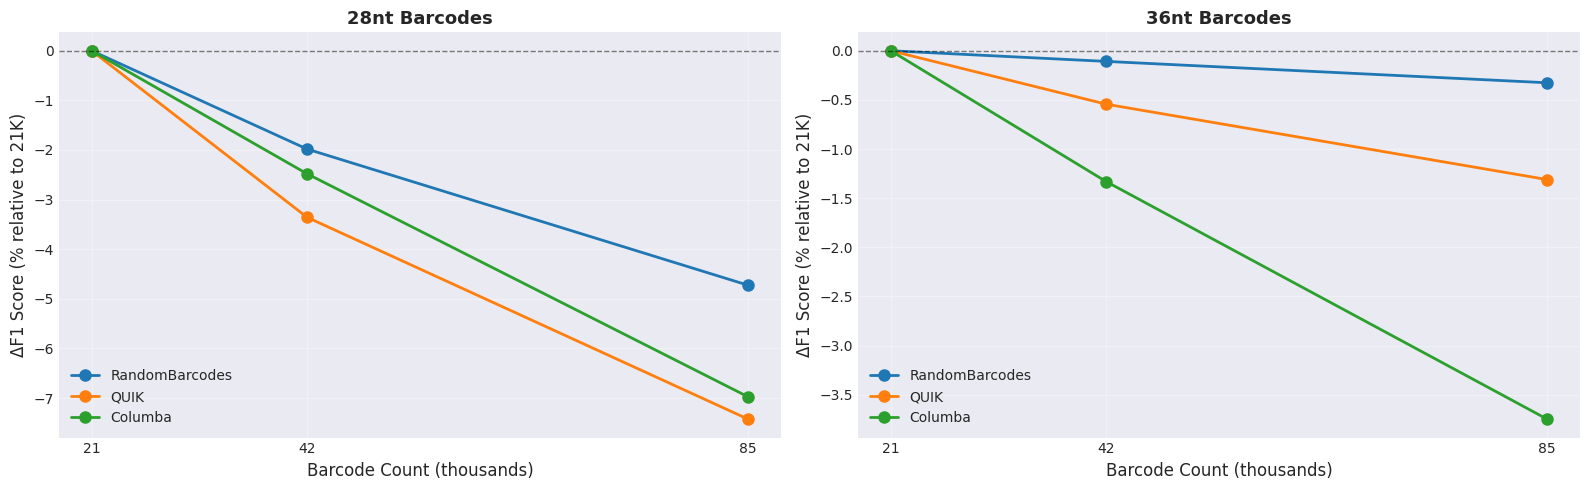

Figure saved to: notebooks/figures/performance_degradation.png


In [63]:
if len(df_all) > 0 and 'optimal_thresholds' in locals() and len(optimal_thresholds) > 0:
    # Calculate performance degradation relative to 21K baseline
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    for i, barcode_length in enumerate(BARCODE_LENGTHS):
        ax = axes[i]
        
        for tool_name in ['RandomBarcodes', 'QUIK', 'Columba']:
            df_tool = df_optimal[
                (df_optimal['tool'] == tool_name) & 
                (df_optimal['barcode_length'] == barcode_length)
            ].sort_values('barcode_count')
            
            if len(df_tool) > 0 and 21000 in df_tool['barcode_count'].values:
                baseline_f1 = df_tool[df_tool['barcode_count'] == 21000]['f1_score'].values[0]
                
                # Calculate delta from baseline
                deltas = []
                counts = []
                for _, row in df_tool.iterrows():
                    delta = row['f1_score'] - baseline_f1
                    deltas.append(delta)
                    counts.append(row['barcode_count']/1000)
                
                ax.plot(counts, deltas, marker='o', label=tool_name, linewidth=2, markersize=8)
        
        ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
        ax.set_xlabel('Barcode Count (thousands)', fontsize=12)
        ax.set_ylabel('ΔF1 Score (% relative to 21K)', fontsize=12)
        ax.set_title(f'{barcode_length}nt Barcodes', fontsize=13, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_xticks([21, 42, 85])
    
    plt.tight_layout()
    plt.savefig('/user/gent/446/vsc44685/ScratchVO_dir/barcalling_review/notebooks/figures/performance_degradation.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Figure saved to: notebooks/figures/performance_degradation.png")

## 6. Summary and Conclusions

In [64]:
if len(df_all) > 0 and 'optimal_thresholds' in locals() and len(optimal_thresholds) > 0:
    print("=" * 80)
    print("SUMMARY: Effect of Barcode Count on Performance")
    print("=" * 80)
    print()
    
    for barcode_length in BARCODE_LENGTHS:
        print(f"\n{barcode_length}nt Barcodes:")
        print("-" * 40)
        
        for tool_name in ['RandomBarcodes', 'QUIK', 'Columba']:
            df_tool = df_optimal[
                (df_optimal['tool'] == tool_name) & 
                (df_optimal['barcode_length'] == barcode_length)
            ].sort_values('barcode_count')
            
            if len(df_tool) > 0:
                print(f"\n  {tool_name}:")
                
                for _, row in df_tool.iterrows():
                    count_label = f"{row['barcode_count']//1000}K"
                    print(f"    {count_label}: Threshold={row['optimal_threshold']:.0f}, " + 
                          f"P={row['precision']:.2f}%, R={row['recall']:.2f}%, F1={row['f1_score']:.2f}%")
                
                # Calculate trend
                if len(df_tool) >= 2:
                    f1_change = df_tool.iloc[-1]['f1_score'] - df_tool.iloc[0]['f1_score']
                    thresh_change = df_tool.iloc[-1]['optimal_threshold'] - df_tool.iloc[0]['optimal_threshold']
                    
                    print(f"    → F1 change (21K→85K): {f1_change:+.2f}%")
                    print(f"    → Threshold change (21K→85K): {thresh_change:+.0f}")
    
    print("\n" + "=" * 80)
    
    # Save summary report
    summary_file = '/user/gent/446/vsc44685/ScratchVO_dir/barcalling_review/notebooks/barcode_count_summary.txt'
    with open(summary_file, 'w') as f:
        f.write("BARCODE COUNT PARAMETER SWEEP - SUMMARY REPORT\n")
        f.write("=" * 80 + "\n\n")
        f.write(f"Generated: {pd.Timestamp.now()}\n\n")
        f.write(f"Total results analyzed: {len(df_all)}\n")
        f.write(f"Tools: RandomBarcodes, QUIK, Columba\n")
        f.write(f"Barcode counts: {', '.join([f'{c//1000}K' for c in BARCODE_COUNTS])}\n")
        f.write(f"Barcode lengths: {', '.join([f'{l}nt' for l in BARCODE_LENGTHS])}\n\n")
        
        f.write(df_optimal.to_string())
    
    print(f"\nSummary report saved to: {summary_file}")

SUMMARY: Effect of Barcode Count on Performance


28nt Barcodes:
----------------------------------------

  RandomBarcodes:
    21K: Threshold=8, P=95.13%, R=76.83%, F1=85.00%
    42K: Threshold=8, P=91.86%, R=75.74%, F1=83.02%
    85K: Threshold=8, P=87.30%, R=74.30%, F1=80.28%
    → F1 change (21K→85K): -4.73%
    → Threshold change (21K→85K): +0

  QUIK:
    21K: Threshold=8, P=95.75%, R=74.33%, F1=83.69%
    42K: Threshold=8, P=92.99%, R=70.71%, F1=80.33%
    85K: Threshold=8, P=88.56%, R=66.97%, F1=76.27%
    → F1 change (21K→85K): -7.43%
    → Threshold change (21K→85K): +0

  Columba:
    21K: Threshold=78, P=94.16%, R=55.84%, F1=70.11%
    42K: Threshold=78, P=89.19%, R=54.46%, F1=67.63%
    85K: Threshold=77, P=80.47%, R=51.94%, F1=63.13%
    → F1 change (21K→85K): -6.98%
    → Threshold change (21K→85K): -1

36nt Barcodes:
----------------------------------------

  RandomBarcodes:
    21K: Threshold=9, P=99.95%, R=64.61%, F1=78.49%
    42K: Threshold=9, P=99.92%, R=64.48%, 

## 7. Export Results

In [65]:
if len(df_all) > 0:
    # Export complete results
    output_file = '/user/gent/446/vsc44685/ScratchVO_dir/barcalling_review/notebooks/barcode_count_sweep_all_results.csv'
    df_all.to_csv(output_file, index=False)
    print(f"All results exported to: {output_file}")
    
    if 'optimal_thresholds' in locals():
        print(f"\nAnalysis complete! Generated {len(optimal_thresholds)} optimal threshold recommendations.")
else:
    print("⚠️  No results to export. Please ensure jobs have completed and results files exist.")

All results exported to: /user/gent/446/vsc44685/ScratchVO_dir/barcalling_review/notebooks/barcode_count_sweep_all_results.csv

Analysis complete! Generated 18 optimal threshold recommendations.
